In [1]:
from typing import List,TypedDict,Literal
from pydantic import BaseModel
import re
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph,START,END

C:\Users\PC\AppData\Local\Temp\ipykernel_11240\2703905915.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [2]:
from langchain_community.tools.tavily_search import  TavilySearchResults
from dotenv import load_dotenv
from langchain_community.vectorstores import Chroma
load_dotenv()

False

In [3]:
docs=PyPDFLoader("C:/Users/PC/OneDrive/Documents/Deep dive into DL.pdf").load()


In [4]:
print(len(docs))

1151


In [5]:
print(docs[20].metadata)

{'producer': 'xdvipdfmx (20210609)', 'creator': 'LaTeX with hyperref', 'creationdate': '2023-08-18T23:22:45+00:00', 'source': 'C:/Users/PC/OneDrive/Documents/Deep dive into DL.pdf', 'total_pages': 1151, 'page': 20, 'page_label': 'xxi'}


In [6]:
# chunking
text_splliter=RecursiveCharacterTextSplitter(chunk_size=500
                                             ,chunk_overlap=50)
chunks=text_splliter.split_documents(docs)

In [7]:
print(len(chunks))

5486


In [8]:
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [9]:
# embeding of chunks
embedding=HuggingFaceEmbeddings(model_name='all-miniLM-L6-v2')
vectorstore=Chroma.from_documents(docs,embedding)


C:\Users\PC\AppData\Local\Temp\ipykernel_11240\2624569007.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding=HuggingFaceEmbeddings(model_name='all-miniLM-L6-v2')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [10]:
from langchain_ollama import OllamaLLM
from langchain_ollama import ChatOllama
retriver=vectorstore.as_retriever()

In [11]:
llm=ChatOllama(model='smollm:135m')
#import openai
#from openai import ChatCompletion
#llm=ChatCompletion(m)

In [12]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [31]:
class State(TypedDict):
    question:str
    docs:List[Document]
    good_docs:List[Document]
    verdict:str
    reason:str
    stirps:List[str]

    kept_strips:List[str]
    refined_context:str
    web_docs:List[Document]
    answer:str
    

In [32]:
def retrive_node(state:State) -> State:
    q=state['question']
    return {'docs': retriver.invoke(q)}

In [33]:
# store based evaluter
class Docevalscore(BaseModel):
    score:float
    reason:str

doc_eval_prompt=ChatPromptTemplate.from_messages(
    [
        (
            'system',
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
            
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

In [34]:
doc_eval_chain=doc_eval_prompt|llm.with_structured_output(Docevalscore)
def eval_each_doc_node(state:State)->State:
    q=state['question']
    scores:List[float]=[]
    good:List[Document]=[]

    for d in state['docs']:
        out=doc_eval_chain.invoke({'question':q,'chunk':d.page_content})
        scores.append(out.scores)

        if out.scores>LOWER_TH:
            good.append(d)
    if any(s>UPPER_TH for s in scores):
        return{
                'good_docs':good,
                'verdict':'CORRECT',
                'reason':f' at least one retrived chunk scored> {UPPER_TH}.',
    if len(scores)>0 and all(s<LOWER_TH for s in scores):
            why='no chunk was sufficient'
            return {
                'good_docs':[],
                'verdict':'incorect',
                'reason':f'all retrivrd chunk scored< {LOWER_TH}. {why}'
                
            }
            why = "Mixed relevance signals."
            return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }
            }

SyntaxError: invalid syntax (2499485197.py, line 18)

In [35]:
doc_eval_chain = doc_eval_prompt | llm.with_structured_output(Docevalscore)

def eval_each_doc_node(state: State) -> State:
    q = state["question"]
    scores: List[float] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)

        if out.score > LOWER_TH:
            good.append(d)

    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [36]:
# sentence level decompodser
def decompos_to_setntace(text:str)->List[str]:
    text=re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]
    

In [37]:
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

In [48]:
# refining
def refine(state: State) -> State:
    q = state['question']
    if state.get('verdict') == 'correct':
        context = '\n\n'.join(d.page_content for d in state['good_docs']).strip()
    else:
        context = '\n\n'.join(d.page_content for d in state['web_docs']).strip()
        
    # Fixed the typo here: changed 'stirps' to 'strips'
    strips = decompos_to_setntace(context) 
    
    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({'question': q, 'sentence': s}).keep:
            kept.append(s)
            
    refined_context = '\n'.join(kept).strip()
    
    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [49]:
import os

os.environ["TAVILY_API_KEY"] = "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"
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()


In [50]:
# -----------------------------
# Web search (Iteration 4)
# Assumption: web search does not fail (no fail node in this branch)
# -----------------------------
tavily = TavilySearchResults()

def web_search_node(state: State) -> State:

    q = state["question"]  # no query rewrite
    results = tavily.invoke({"query": q})  # no knowledge selection

    web_docs = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [51]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [52]:
def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

In [53]:
# -----------------------------
# Graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrive_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("web_search", web_search_node)
g.add_node("refine", refine)          # uses verdict to pick good_docs vs web_docs
g.add_node("generate", generate)
g.add_node("ambiguous", ambiguous_node)

# flow
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

# route after evaluation
g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",          # CORRECT -> refine (good_docs)
        "web_search": "web_search",  # INCORRECT -> web_search
        "ambiguous": "ambiguous",    # AMBIGUOUS -> end (your current choice)
    },
)


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


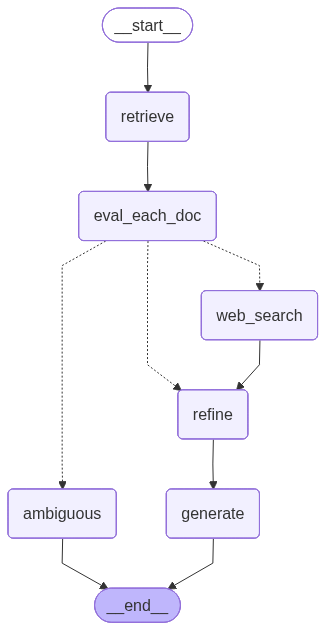

In [66]:
# ✅ key change: web_search now goes through refine
#g.add_edge("web_search", "refine")    # INCORRECT -> refine (web_docs)
g.add_edge("refine", "generate")      # CORRECT/INCORRECT -> generate

g.add_edge("generate", END)
g.add_edge("ambiguous", END)

app = g.compile()
app

In [ ]:
res = app.invoke(
    {
        "question": "who is founder of spacex",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

In [ ]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

In [10]:
def get_final_answers(input):
    final_answers = [2,3]

    for i in range(len(input) - 1):
        final_answer = input[i]
        if final_answer == 'AI News':
            final_answers.append('AI News')
        elif final_answer == 'Current Stock Market':
            final_answers.append(final_answer)

    return final_answers

In [11]:
print(get_final_answers('ai news'))

[2, 3]


In [12]:
ques=input('enter question')

enter question ravi
